# Exam Scheduling — Experiment Notebook

**Sections**
1. [Setup & Imports](#Setup)
2. [Batch Management](#Batch-Management)
3. [Config](#Config)
4. [Load Datasets](#Load-Datasets)
5. [Run Experiments](#Run-Experiments)
6. [Results Table](#Results-Table)
7. [Aggregated Export](#Aggregated-Results-&-Export)
8. [Experiment Summary Plots](#Experiment-Summary)
9. [Parameter Sweep](#Parameter-Sweep)
10. [Generate Synthetic Instances](#Generate-Synthetic-Instances)
11. [Auto-Tuner](#Auto-Tuner)
12. [Synthetic Size Scan — Best Chain](#Synthetic-Size-Scan)
13. [Utilities & Reset](#Reset-&-Utilities)

> All solvers route through the C++ binary (`cpp/build/exam_solver`). Python
> handles parsing, batch bookkeeping, and plotting only.


In [1]:
import os, sys, importlib
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
from IPython.display import display

from core.parser import parse_itc2007_exam
from core.generator import generate_synthetic, write_itc2007_format
from algorithms.cpp_bridge import run_solver
from utils.results_logger import ResultsLogger
from utils.batch_manager import BatchManager

# Reload-then-wildcard imports so re-running this cell picks up plotting edits.
import utils.plotting
importlib.reload(utils.plotting)
from utils.plotting import *   # noqa: F401,F403
import matplotlib.pyplot as plt

try:
    from algorithms.ip_solver import solve_ip
    HAS_IP = True
except ImportError:
    HAS_IP = False

bm = BatchManager()
print("Ready — all solvers route through C++ binary.")


Ready — all solvers route through C++ binary.


## Batch Management

In [2]:
# BATCH_MODE: "new" (create) or "load" (resume/view existing).
# BATCH_LOAD accepts int id, dirname, or partial name match.
BATCH_MODE = "load"
BATCH_NAME = "tunning8"
BATCH_LOAD = "batch_017_tunning8"

if BATCH_MODE == "load":
    bm.load_batch(BATCH_LOAD)
else:
    bm.new_batch(BATCH_NAME)

logger = bm.logger
print(f"Active batch: {os.path.basename(bm.active_dir)}")
print(f"Records: {len(logger.load_all())}")


[Batch] Loaded: batch_017_tunning8
Active batch: batch_017_tunning8
Records: 97


In [ ]:
bm.list_batches()


## Config

In [3]:
from tooling.tuned_params import load_params_flat

DATASETS = {f"exam_comp_set{i}": f"instances/exam_comp_set{i}.exam"
            for i in range(1, 9)}

# Algorithm selector — single name, comma list, or "all".
ALGO = "all"

# "individual" — run each algo separately. "chain" — warm-started chain.
EXPERIMENT_MODE = "individual"
EXPERIMENT_CHAIN = None   # None = auto-load tuned best chain from tuned_params.json

# Tuned defaults. load_params_flat() always returns the full key set.
PARAMS = load_params_flat()

SEED          = 42
NUM_TRIALS    = 1
RUN_IP        = False       # Python IP fallback (small instances only)
IP_TIME_LIMIT = 120
VERBOSE       = True

_src = "tooling/tuned_params.json" if os.path.isfile("tooling/tuned_params.json") else "hardcoded fallback"
print(f"Params source: {_src}")


Params source: tooling/tuned_params.json


## Load Datasets

In [ ]:
problems = {}
for name, path in DATASETS.items():
    if not os.path.isfile(path):
        print(f"SKIP: {path} not found"); continue
    problems[name] = p = parse_itc2007_exam(path)
    print(f"{name}: {p.num_exams()} exams, {p.num_periods()} periods, "
          f"{p.num_rooms()} rooms, {p.num_students()} students, "
          f"density={p.conflict_density():.3f}")
print(f"\nLoaded {len(problems)} dataset(s)")


## Run Experiments

In [ ]:
# Two modes share the per-dataset header + per-trial loop. Helpers below
# keep each mode's inner loop tight.

def _run_chain_mode(logger, problems, datasets, chain, num_trials, seed):
    from algorithms.cpp_bridge import run_chain as _run_chain
    label = "Chain(" + "→".join(s[0] for s in chain) + ")"
    print(f"Chain mode — {label}")
    for ds_name, ds_path in datasets.items():
        if ds_name not in problems: continue
        p = problems[ds_name]
        print(f"\n{'='*60}\n  {ds_name} ({p.num_exams()} exams)\n{'='*60}")
        for trial in range(num_trials):
            s = seed + trial * 1000
            r = _run_chain(ds_path, chain, seed=s)
            if r is None:
                print(f"  [{label}] t={trial} FAILED"); continue
            cfg = {"chain": [(a, dict(pp)) for a, pp in chain], "seed": s}
            rec = logger.log_run(ds_name, p, r, config=cfg, trial=trial)
            yield rec
            ev = r["evaluation"]
            print(f"  [{label:<22}] t={trial}  feasible={ev.hard == 0}  "
                  f"hard={ev.hard}  soft={ev.soft:>8}  time={r['runtime']:.3f}s  "
                  f"mem={r['memory_peak_mb']:.1f}MB")


def _run_individual_mode(logger, problems, datasets, algo, params,
                          num_trials, seed, verbose, run_ip, ip_limit, has_ip):
    for ds_name, ds_path in datasets.items():
        if ds_name not in problems: continue
        p = problems[ds_name]
        print(f"\n{'='*60}\n  {ds_name} ({p.num_exams()} exams)\n{'='*60}")
        for trial in range(num_trials):
            s = seed + trial * 1000
            results = run_solver(ds_path, algo=algo, seed=s, verbose=verbose, **params)
            for algo_name, r in results.items():
                if algo_name == "Greedy" and trial > 0:
                    continue
                cfg = {**params, "seed": s}
                rec = logger.log_run(ds_name, p, r, config=cfg, trial=trial)
                yield rec
                ev = r["evaluation"]
                feas = getattr(ev, "feasible", getattr(ev, "is_feasible", None))
                soft = getattr(ev, "soft", getattr(ev, "soft_penalty", None))
                hard = getattr(ev, "hard", getattr(ev, "hard_violations", None))
                print(f"  [{algo_name:<22}] t={trial}  feasible={feas}  "
                      f"hard={hard}  soft={soft:>8}  time={r['runtime']:.3f}s")
            if run_ip and has_ip and p.num_exams() <= 300:
                r = solve_ip(p, time_limit=ip_limit, verbose=verbose)
                yield logger.log_run(ds_name, p, r,
                                      config={"ip_time_limit": ip_limit}, trial=trial)


session_records = []
if EXPERIMENT_MODE == "chain":
    from tooling.tuned_params import load_best_chain
    chain = EXPERIMENT_CHAIN or load_best_chain()
    if not chain:
        raise RuntimeError("chain mode requires EXPERIMENT_CHAIN or a tuned best_chain")
    session_records = list(_run_chain_mode(logger, problems, DATASETS, chain, NUM_TRIALS, SEED))
else:
    session_records = list(_run_individual_mode(
        logger, problems, DATASETS, ALGO, PARAMS,
        NUM_TRIALS, SEED, VERBOSE, RUN_IP, IP_TIME_LIMIT, HAS_IP))

print(f"\nLogged {len(session_records)} records this session")
print(f"Total in log: {len(logger.load_all())}")


## Results Table

In [4]:
df = logger.to_dataframe()
if df.empty:
    print("No results logged yet — run the experiments cell above.")
else:
    print(f"{len(df)} rows | algos: {df['algorithm'].nunique()} | datasets: {df['dataset'].nunique()}")
    display(df.head(15))


97 rows | algos: 13 | datasets: 8


,timestamp,dataset,trial,notes,num_exams,num_periods,num_rooms,num_students,conflict_density,num_period_constraints,...,cfg_ga_pop,cfg_ga_iters,cfg_lahc_iters,cfg_lahc_list,cfg_woa_pop,cfg_woa_iters,cfg_cpsat_time,cfg_vns_iters,cfg_vns_budget,cfg_seed
0,2026-04-13T00:25:11.389850,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
1,2026-04-13T00:25:11.390186,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
2,2026-04-13T00:25:11.390314,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
3,2026-04-13T00:25:11.390409,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
4,2026-04-13T00:25:11.390521,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
5,2026-04-13T00:25:11.390597,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
6,2026-04-13T00:25:11.390657,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
7,2026-04-13T00:25:11.390747,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
8,2026-04-13T00:25:11.390838,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42
9,2026-04-13T00:25:11.390924,exam_comp_set1,0,,607,54,7,7883,0.0505,12,...,50,500,5000,0,25,3000,60.0,5000,0,42


## Aggregated Results & Export

In [ ]:
agg_path = logger.save_aggregated()
print(f"Wrote: {agg_path}")
agg = pd.read_csv(agg_path) if os.path.isfile(agg_path) else None
if agg is not None:
    display(agg.head(15))


## Experiment Summary

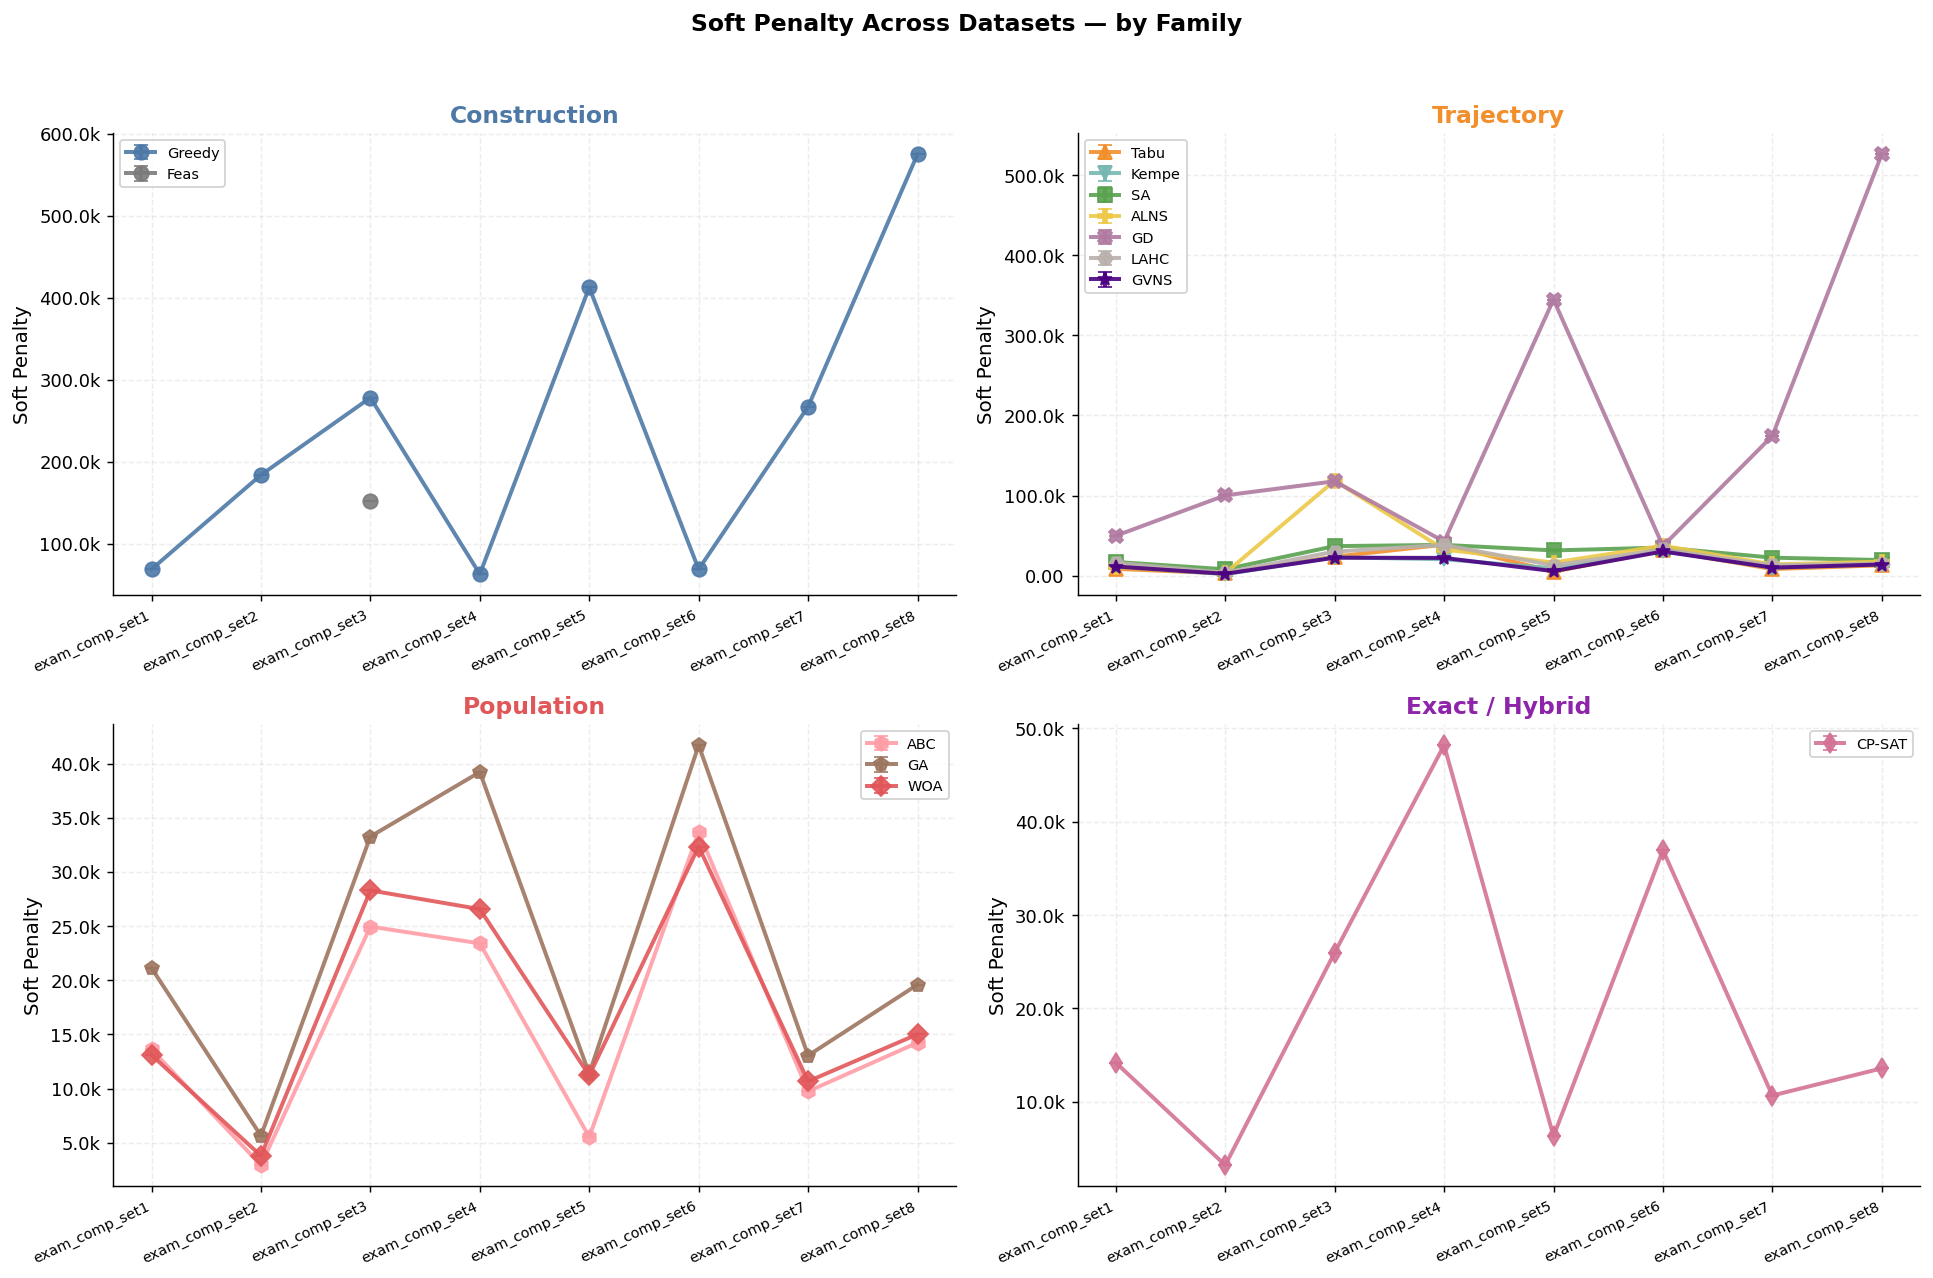

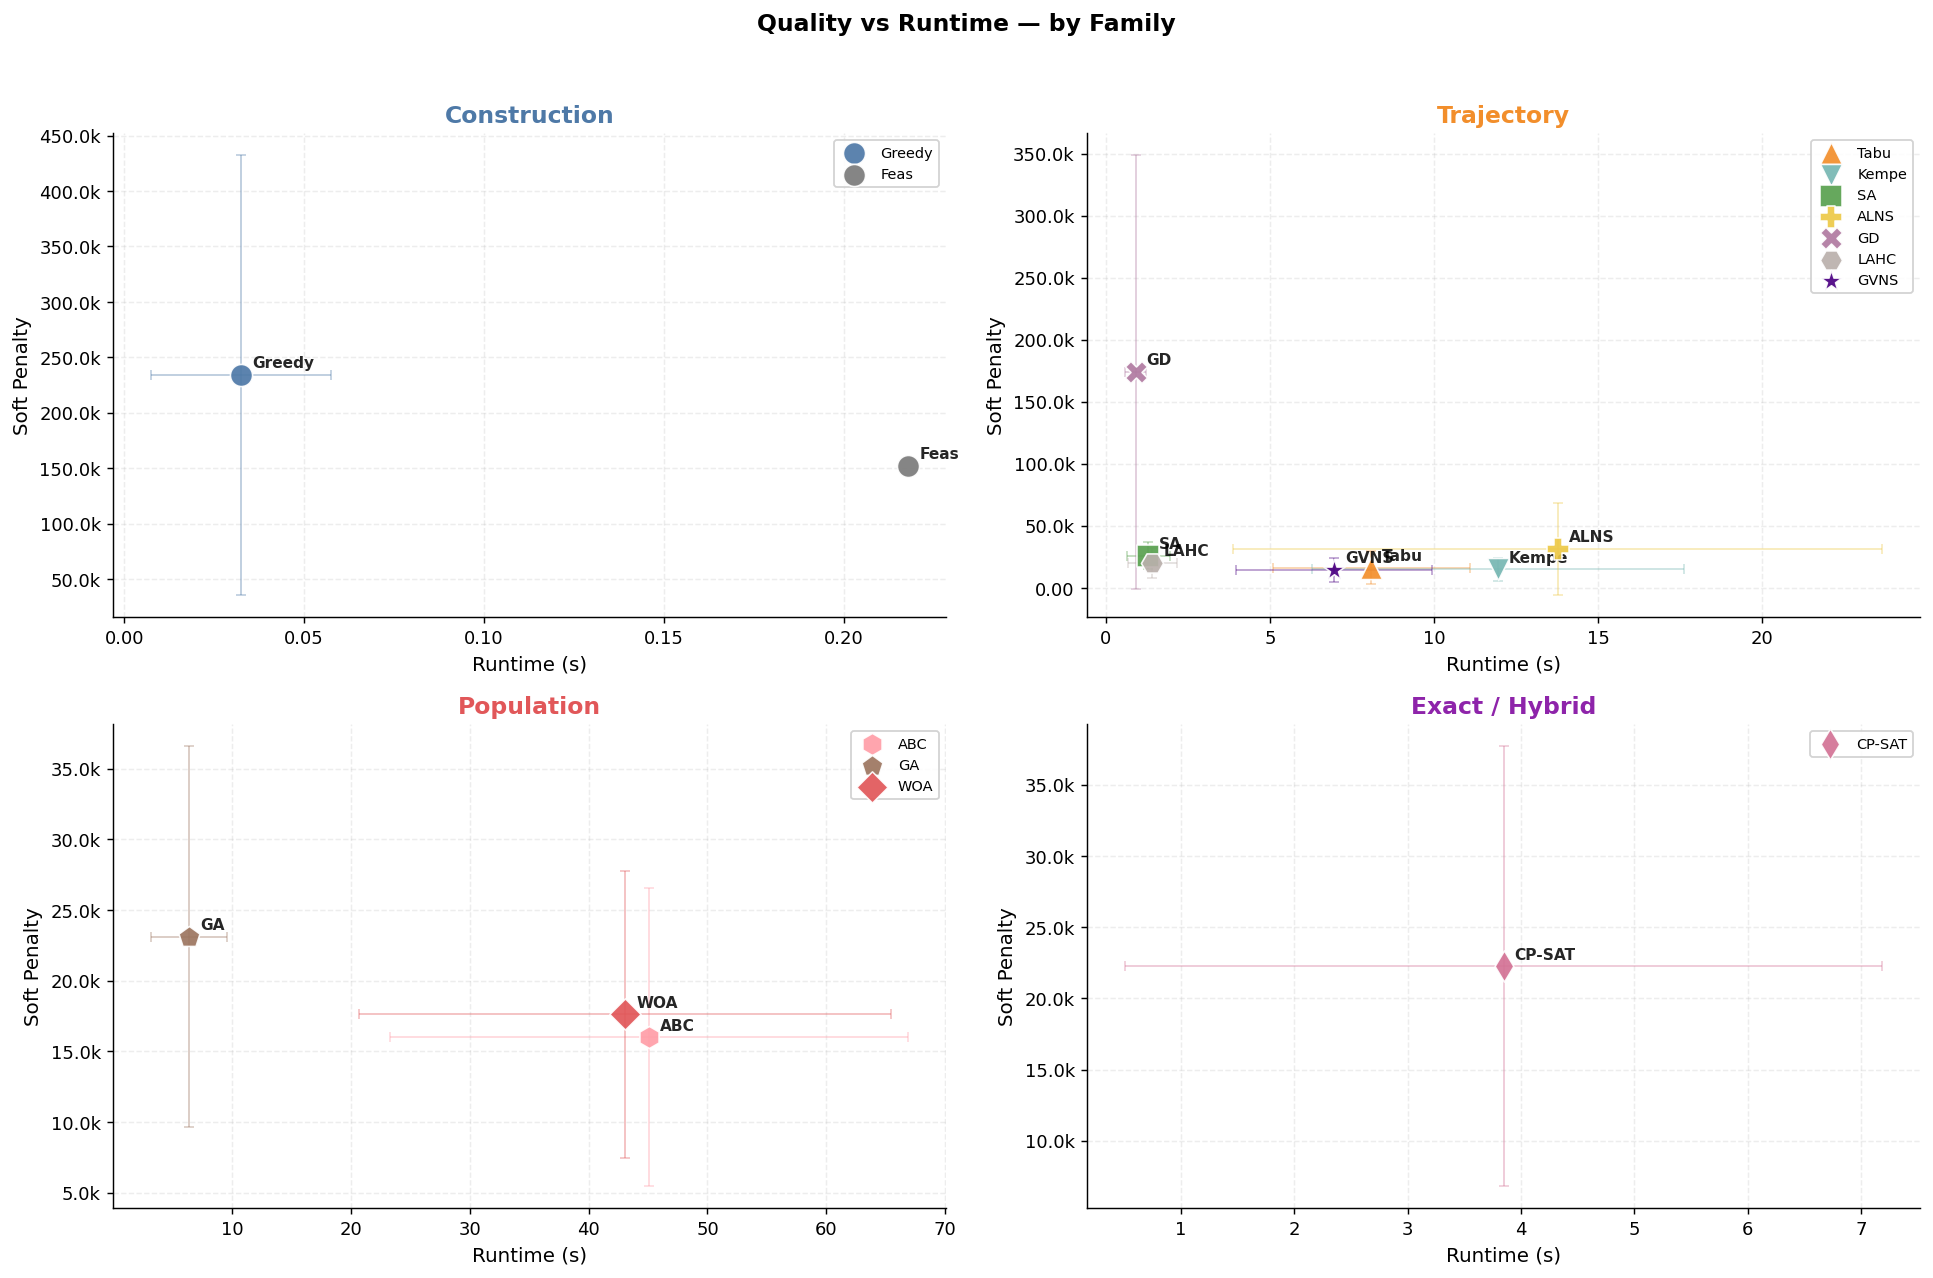

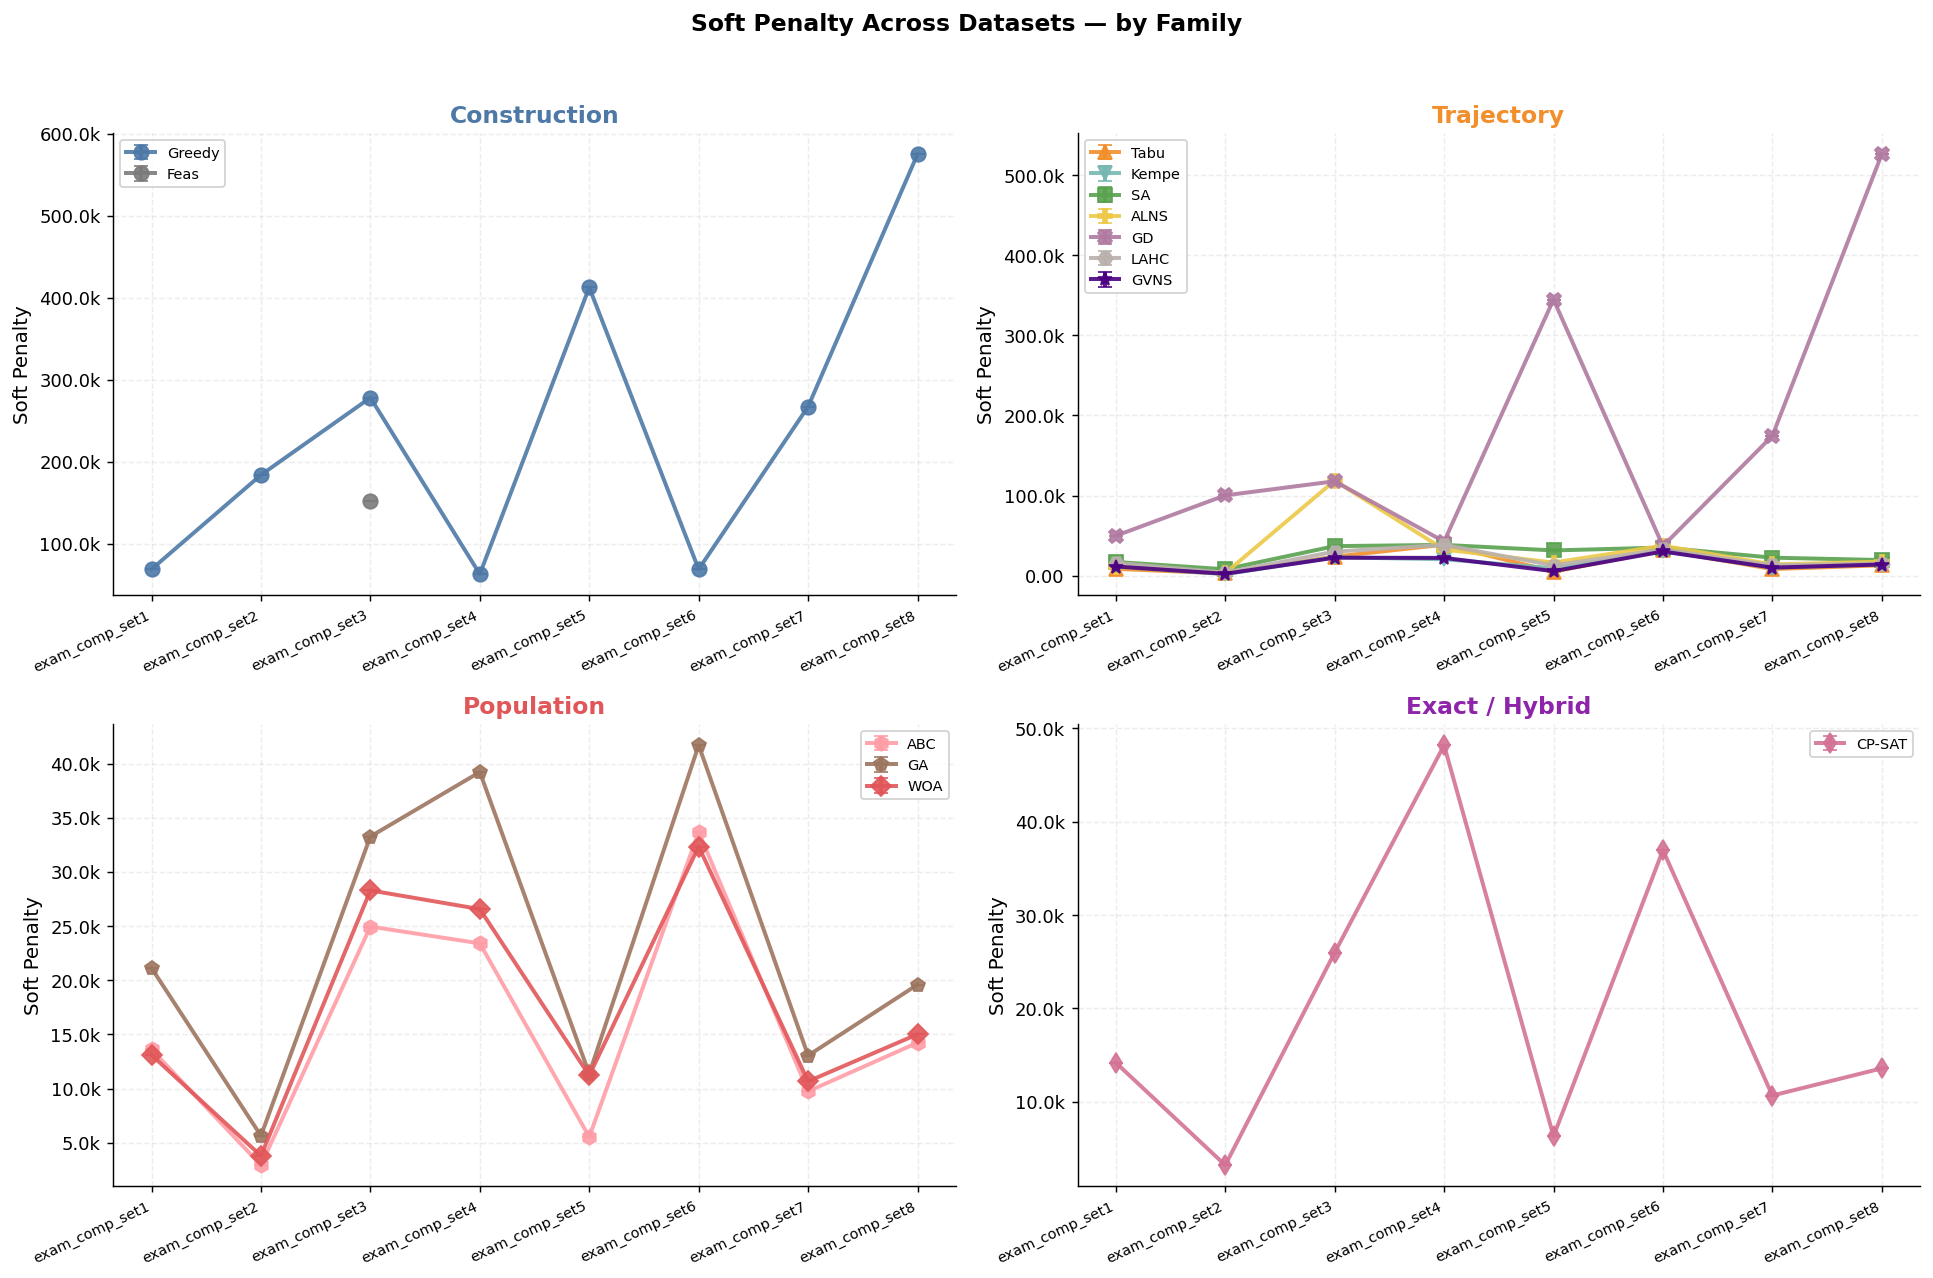

In [5]:
# plot_experiment_summary / algo_bars / algo_boxes / algo_radar / algo_scatter /
# algo_heatmap are all in utils.plots.* (re-exported via utils.plotting).
plot_experiment_summary(df)   # line: soft + runtime + memory across datasets
plot_algo_bars(df)            # horizontal bars for soft/runtime/memory
plot_algo_boxes(df)           # boxplot of soft-penalty distribution
plot_algo_radar(df)           # normalised performance radar
plot_algo_scatter(df)         # quality vs runtime scatter
plot_algo_heatmap(df)         # algorithm × dataset soft heatmap

# Paper-quality family facets (readable at 13 algos):
plot_runtime_vs_quality(df, by_family=True)
plot_line_across_datasets(df, metric="soft_penalty", by_family=True)


## Parameter Sweep

In [ ]:
# Sweep one parameter, three trials per value, plot sensitivity.
SWEEP_ALGO    = "tabu"          # "tabu","sa","kempe","alns","gd","abc","ga","lahc","woa","vns"
SWEEP_PARAM   = "tabu_iters"
SWEEP_DATASET = list(DATASETS.keys())[0]
PARAM_VALUES  = [100, 250, 500, 1000, 2000, 3000]
SWEEP_TRIALS  = 3

sweep_records = []
_swp_path     = DATASETS[SWEEP_DATASET]
_swp_problem  = problems[SWEEP_DATASET]

for val in PARAM_VALUES:
    for trial in range(SWEEP_TRIALS):
        s = 42 + trial * 1000
        results = run_solver(_swp_path, algo=SWEEP_ALGO, seed=s, verbose=False,
                             **{SWEEP_PARAM: val})
        for _, r in results.items():
            rec = logger.log_run(SWEEP_DATASET, _swp_problem, r,
                                  config={SWEEP_PARAM: val, "seed": s},
                                  trial=trial, notes=f"sweep_{SWEEP_PARAM}_{val}")
            sweep_records.append(rec)
        print(f"  {SWEEP_PARAM}={val} t={trial}: soft={rec['soft_penalty']} time={rec['runtime']:.2f}s")

sdf = pd.DataFrame(sweep_records)
sdf["sweep_val"] = sdf["config"].apply(lambda c: c.get(SWEEP_PARAM, 0))
plot_parameter_sensitivity(sdf, "sweep_val", metric="soft_penalty",
                           algorithm=sweep_records[0]["algorithm"])
plt.xlabel(SWEEP_PARAM); plt.show()


## Generate Synthetic Instances

In [ ]:
SYNTH_CONFIGS = [(342, "competition"), (675, "competition"), (879, "competition")]

os.makedirs("instances", exist_ok=True)
generated = []
for n, preset in SYNTH_CONFIGS:
    path = f"instances/synthetic_{preset}_{n}.exam"
    if not os.path.isfile(path):
        p = generate_synthetic(num_exams=n, preset=preset, seed=42 + n)
        write_itc2007_format(p, path); tag = "generated"
    else:
        p = parse_itc2007_exam(path); tag = "exists"
    generated.append((n, preset, path, p))
    print(f"  [{tag}] {path}: {p.num_exams()} exams, {p.num_periods()} periods, "
          f"{p.num_rooms()} rooms, density={p.conflict_density():.3f}")

print(f"\n{len(generated)} synthetic datasets ready in instances/")


## Auto-Tuner

In [ ]:
import glob as globmod, json
from tooling import auto_tuner as _at
importlib.reload(_at)
AutoTuner = _at.AutoTuner
generate_synthetic_dataset = _at.generate_synthetic_dataset
from tooling.tuned_params import load_metadata, list_versions

# All ITC 2007 public sets + (optional) competition-scale synthetics.
TUNE_DATASETS = sorted(globmod.glob("instances/exam_comp_set*.exam"))
TUNE_OUTPUT   = os.path.join(bm.active_dir, "tuning")
INCLUDE_SYNTH = True
SYNTH_CONFIGS = [(342, "competition"), (675, "competition"), (879, "competition"),
                 (569, "competition"), (710, "competition")]

if INCLUDE_SYNTH:
    syn_dir = os.path.join(TUNE_OUTPUT, "_synthetic")
    for size, preset in SYNTH_CONFIGS:
        TUNE_DATASETS.append(generate_synthetic_dataset(
            syn_dir, num_exams=size, preset=preset, seed=SEED + size))

print(f"Tuning on {len(TUNE_DATASETS)} datasets:")
for d in TUNE_DATASETS: print(f"  {os.path.basename(d)}")

tuner = AutoTuner(
    datasets=TUNE_DATASETS, output_dir=TUNE_OUTPUT,
    max_workers=5, param_trials=3, chain_pop=4, chain_rounds=2,
    max_time=2400, eval_datasets=2, seed=SEED, auto_update=True,
)
tuner.run()

# Post-run report.
report_path = os.path.join(TUNE_OUTPUT, "tuning_report.json")
if os.path.isfile(report_path):
    rpt = json.load(open(report_path))
    score = rpt["best_score"]
    fmt = f"{score:.4f}" if score < 100 else f"{score:.0f}"
    print(f"\nBest score: {fmt}")
    print(f"Best config: {rpt['best_config']}")
else:
    print("\nNo report generated (possibly timed out before final phase)")

meta = load_metadata()
if meta:
    print(f"\nActive golden params: v{meta.get('version', '?')} "
          f"(score={meta.get('aggregate_score', '?')}, {meta.get('source', '?')})")
for v, ts, sc, src in (list_versions() or [])[-3:]:
    print(f"  v{v} score={sc} ({src})")


## Synthetic Size Scan — Best Chain

In [ ]:
from tooling.tuned_params import load_best_chain

# Default: use the tuned best chain from tooling/tuned_params.json.
chain = load_best_chain() or [("sa", {}), ("gd", {})]
chain_label = "Chain(" + "→".join(s[0] for s in chain) + ")"

SCAN_SIZES = [300, 500, 700, 900]
SCAN_SEEDS = [42, 123, 456]
SCAN_PRESET = "competition"
print(f"Scan chain: {chain_label} — sizes {SCAN_SIZES} × {len(SCAN_SEEDS)} seeds")


In [ ]:
from algorithms.cpp_bridge import run_chain
from utils.plotting import plot_continuous_scan

scan_records = []
for n in SCAN_SIZES:
    path = f"instances/synthetic_scan_{n}.exam"
    if not os.path.isfile(path):
        p = generate_synthetic(num_exams=n, preset=SCAN_PRESET, seed=42 + n)
        write_itc2007_format(p, path)
    for s in SCAN_SEEDS:
        r = run_chain(path, chain, seed=s)
        if r is None:
            print(f"  n={n} seed={s}: FAILED"); continue
        scan_records.append({"num_exams": n, "seed": s,
                              "soft_penalty": r["soft_penalty"],
                              "runtime": r["total_runtime"],
                              "memory_peak_mb": r["memory_peak_mb"]})
    done = len([r for r in scan_records if r["num_exams"] == n])
    print(f"  n={n}: {done}/{len(SCAN_SEEDS)} seeds done")

scan_df = pd.DataFrame(scan_records)
display(scan_df.groupby("num_exams").agg({
    "soft_penalty":   ["mean", "std"],
    "runtime":        ["mean", "std"],
    "memory_peak_mb": ["mean", "std"],
}).round(2))
plot_continuous_scan(scan_df, title=f"Synthetic Scan — {chain_label}")
plt.show()


## Reset & Utilities

In [ ]:
# Active-batch stats
_all = logger.load_all()
print(f"Records: {len(_all)}")
if _all:
    algos = sorted({r['algorithm'] for r in _all})
    dsets = sorted({r['dataset']  for r in _all})
    print(f"Algos    ({len(algos)}): {algos}")
    print(f"Datasets ({len(dsets)}): {dsets}")


In [ ]:
# Clear the ACTIVE BATCH's log (destructive — no undo).
# Uncomment to run.
# logger.clear_all()
# print("Cleared active batch's log.")


In [ ]:
# Switch the active batch without re-running imports.
# bm.load_batch("batch_017_tunning8")
# logger = bm.logger
# print(f"Switched to: {os.path.basename(bm.active_dir)}")


In [ ]:
# Remove *.png files from batch directories — handy when regenerating figures.
# Usage:
#   clear_batch_pngs("baseline")                        partial name/id match
#   clear_batch_pngs(bm.active_dir)                     the active batch
#   clear_batch_pngs(all_batches=True)                  every batch_*/
#   clear_batch_pngs(all_batches=True, include_best=True)
#   clear_batch_pngs(all_batches=True, dry_run=True)    preview
def clear_batch_pngs(batch=None, all_batches=False, include_best=False, dry_run=False):
    import glob as _glob
    targets = []
    if all_batches:
        targets += sorted(_glob.glob("results/batch_*"))
        if include_best:
            targets += sorted(_glob.glob("results/best/batch_*"))
    elif batch is not None:
        b = str(batch)
        if os.path.isdir(b):
            targets.append(b)
        else:
            hits = sorted(_glob.glob(f"results/batch_*{b}*"))
            if not hits and b.isdigit():
                hits = sorted(_glob.glob(f"results/batch_{int(b):03d}_*"))
            if not hits:
                print(f"No batch matching: {batch!r}"); return
            targets += hits
    else:
        print("Provide batch=... or all_batches=True"); return

    total = 0
    for d in targets:
        pngs = _glob.glob(f"{d}/*.png")
        if not pngs: continue
        lbl = os.path.basename(d)
        if dry_run:
            print(f"  [dry] {lbl}: would remove {len(pngs)} png(s)")
        else:
            for p in pngs:
                try: os.remove(p)
                except OSError: pass
            print(f"  {lbl}: removed {len(pngs)} png(s)")
        total += len(pngs)
    print(f"{'Would remove' if dry_run else 'Removed'} {total} PNG(s) across {len(targets)} batch(es)")
